<a href="https://colab.research.google.com/github/Bootcamp-DA-P3/Python-Analisis_Diego-Ramon/blob/main/LimpiezaR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
#Inicializamos la librería "pandas"
import pandas as pd

# Cargamos el archivo CSV
df = pd.read_csv('/content/drive/MyDrive/Python-Analisis_Diego-Ramon/kiva_loans_42304_rows.csv')

# Mostramos las primeras filas del archivo para tener una visión inicial de cómo están organizados los datos
df.head()

,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,partner_id,posted_time,disbursed_time,funded_time,term_in_months,lender_count,tags,borrower_genders,repayment_interval,date
0,1175609,525.0,525.0,Personal Medical Expenses,Health,to buy medicines for her son’s treatment at th...,TJ,Tajikistan,Kanibadam,TJS,100.0,2016-10-27 04:54:27+00:00,2016-10-04 07:00:00+00:00,2016-11-05 02:14:03+00:00,14.0,18,#Health and Sanitation,female,monthly,2016-10-27
1,1056732,350.0,350.0,Butcher Shop,Food,to buy a refrigerator for his butcher shop,MX,Mexico,Ecatepec,MXN,294.0,2016-04-19 15:55:26+00:00,2016-03-31 07:00:00+00:00,2016-04-25 20:14:08+00:00,8.0,10,"#Elderly, #First Loan, #Health and Sanitation,...",male,monthly,2016-04-19
2,773348,225.0,225.0,Food,Food,to buy more raw ingredients for making food sn...,PH,Philippines,"Plaridel-Unidos, Plaridel, Misamis Occidental",PHP,126.0,2014-09-23 08:53:49+00:00,2014-09-19 07:00:00+00:00,2014-10-04 14:33:45+00:00,11.0,9,"volunteer_pick, volunteer_like, #Woman Owned Biz",female,irregular,2014-09-23
3,1076908,325.0,325.0,Farming,Agriculture,to purchase sacks of fertilizer,PH,Philippines,"Pagadian City, Zamboanga del Sur",PHP,126.0,2016-05-27 08:40:46+00:00,2016-05-10 07:00:00+00:00,2016-06-02 12:04:03+00:00,7.0,7,user_favorite,female,irregular,2016-05-27
4,680170,500.0,500.0,Poultry,Agriculture,To purchase more broiler chicks,ZW,Zimbabwe,Nyanga,USD,305.0,2014-03-06 10:29:22+00:00,2014-03-05 08:00:00+00:00,2014-04-02 01:31:55+00:00,8.0,11,"#Woman Owned Biz, #Parent, #Low-profit FP",female,irregular,2014-03-06


In [ ]:
# Mostramos las columnas
df.columns

Index(['id', 'funded_amount', 'loan_amount', 'activity', 'sector', 'use',
       'country_code', 'country', 'region', 'currency', 'partner_id',
       'posted_time', 'disbursed_time', 'funded_time', 'term_in_months',
       'lender_count', 'tags', 'borrower_genders', 'repayment_interval',
       'date'],
      dtype='object')

In [ ]:
# Mostramos los tipos de datos que son las columnas
df.dtypes

,0
id,int64
funded_amount,float64
loan_amount,float64
activity,object
sector,object
use,object
country_code,object
country,object
region,object
currency,object


In [ ]:
# Convertimos las columnas que son una fecha (y son otro tipo distinto de dato) a tipo datetime
df['funded_time'] = pd.to_datetime(df['funded_time'], errors='coerce')
df['disbursed_time'] = pd.to_datetime(df['disbursed_time'], errors='coerce')
df['posted_time'] = pd.to_datetime(df['posted_time'], errors='coerce')

# Comprobamos que los cambios se han producido
df.dtypes

,0
id,int64
funded_amount,float64
loan_amount,float64
activity,object
sector,object
use,object
country_code,object
country,object
region,object
currency,object


En las siguientes celdas procedemos a comprobar si hay duplicados exactos en el data set, es decir, si hay filas que son exactamente idénticas en todas sus columnas.

Si fuera el caso eliminaríamos una de las filas duplicadas ya que no aportaría nada al dataset. En este caso no hay duplicados.

In [ ]:
# Comprobamos cuántos duplicados exactos existen en todo el DataFrame
duplicados_totales = df.duplicated().sum()
print(f"Número de filas duplicadas exactas en total: {duplicados_totales}")


Número de filas duplicadas exactas en total: 0


In [ ]:
# 3 Comprobamos duplicados en la columna 'id' (se supone que es un identificador único)
duplicados_id = df.duplicated(subset=['id']).sum()
print(f"Número de préstamos con 'id' repetido: {duplicados_id}")

Número de préstamos con 'id' repetido: 0


In [ ]:
# 5. Confirmar el tamaño final del DataFrame limpio
print(f"Nuevo total de filas tras eliminar duplicados: {df.shape[0]}")

Nuevo total de filas tras eliminar duplicados: 42308


En las siguiente celdas analizaremos si hay valores nulos o faltantes en las celdas del dataset.

Primero veremos la cantidad de nulos que hay, y luego decidiremos que estrategia se debe llevar a cabo.

Puede haber casos que los valores nulos aporten información y no deban ser descartados

In [ ]:
# Contamos la cantidad de valores nulos y su porcentaje en cada columna
nulos = df.isnull().sum()
porcentaje = (df.isnull().sum() / len(df)) * 100

#Hacemos una pequeña tabla con el número de nulos y su porcentaje para facilitar la visualización
resumen_nulos = pd.DataFrame({
    'nulos': nulos,
    'porcentaje (%)': porcentaje.round(2)
})
print(resumen_nulos)

                    nulos  porcentaje (%)
id                      0             0.0
funded_amount           0             0.0
loan_amount             0             0.0
activity                0             0.0
sector                  0             0.0
use                     0             0.0
country_code            0             0.0
country                 0             0.0
region                  0             0.0
currency                0             0.0
partner_id              0             0.0
posted_time             0             0.0
disbursed_time          0             0.0
funded_time             0             0.0
term_in_months          0             0.0
lender_count            0             0.0
tags                    0             0.0
borrower_genders        0             0.0
repayment_interval      0             0.0
date                    0             0.0


Vemos que no hay ningún dato nulo

Puede que haya valores que representen un valor nulo pero el código no los identifique como tales.

Para ello sustituiremos esos valores por NaN y repetiremos el proceso anterior.

In [ ]:
# Sustituimos los valores (que son típicos de datasets) entre corchetes por un valor que el código detecta como nulo o faltante
df.replace(['', 'NA', 'N/A', 'null', 'None'], pd.NA, inplace=True)

# Repetimos el proceso anterior
nulos = df.isnull().sum()
porcentaje = (df.isnull().sum() / len(df)) * 100

resumen_nulos = pd.DataFrame({
    'nulos': nulos,
    'porcentaje (%)': porcentaje.round(2)
})
print(resumen_nulos)

                    nulos  porcentaje (%)
id                      0             0.0
funded_amount           0             0.0
loan_amount             0             0.0
activity                0             0.0
sector                  0             0.0
use                     0             0.0
country_code            0             0.0
country                 0             0.0
region                  0             0.0
currency                0             0.0
partner_id              0             0.0
posted_time             0             0.0
disbursed_time          0             0.0
funded_time             0             0.0
term_in_months          0             0.0
lender_count            0             0.0
tags                    0             0.0
borrower_genders        0             0.0
repayment_interval      0             0.0
date                    0             0.0


In [ ]:
# 1. Definir las columnas de texto que vas a normalizar
columnas_texto = ['country', 'currency', 'sector', 'activity']

# 2. Aplicar trim (eliminar espacios blancos) y lower (minúsculas)
for col in columnas_texto:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.lower()

# 3. Definir tus mapeos de estandarización (ejemplo de correcciones)
mapeo_paises = {
    'united states': 'estados unidos',
    'us': 'estados unidos',
    'uk': 'reino unido',
    'united kingdom': 'reino unido'
}

# 4. Aplicar el mapeo en la columna correspondiente
df['country'] = df['country'].replace(mapeo_paises)


# Con el df.head muestra las 5 primeras filas y columnas todas en minusculas.

df[['country', 'currency', 'sector', 'activity']].head()


,country,currency,sector,activity
0,tajikistan,tjs,health,personal medical expenses
1,mexico,mxn,food,butcher shop
2,philippines,php,food,food
3,philippines,php,agriculture,farming
4,zimbabwe,usd,agriculture,poultry


In [ ]:
# ==============================================================================
# ETAPA: CORRECCIÓN DE FORMATOS Y TIPOS NUMÉRICOS
# Operaciones: Limpieza de símbolos, conversión de coma a punto y cambio de tipo
# ==============================================================================

# 1. Definir las columnas que deberían ser números decimales (precios/montos)
columnas_decimales = ['funded_amount', 'loan_amount']

# 2. Definir las columnas que deberían ser números enteros (conteos/meses)
columnas_enteras = ['term_in_months', 'lender_count']

# 3. Limpieza y conversión para columnas decimales (Float)
for col in columnas_decimales:
    if col in df.columns:
        # Convertimos a texto temporalmente para poder limpiar los caracteres
        df[col] = df[col].astype(str).str.strip()

        # ELIMINACIÓN DE FORMATO:
        # Si tus miles usan punto (ej: 1.000,50), quitamos el punto primero:
        # df[col] = df[col].str.replace('.', '', regex=False)

        # Cambiamos la coma decimal por punto para que Python lo entienda (ej: 12,50 -> 12.50)
        df[col] = df[col].str.replace(',', '.', regex=False)

        # Eliminamos signos de dólar o cualquier otro carácter no numérico si existiera
        df[col] = df[col].str.replace('$', '', regex=False)

        # Convertimos formalmente la columna a tipo numérico decimal (float)
        # errors='coerce' transforma cualquier texto corrupto o vacío en un valor nulo (NaN)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 4. Limpieza y conversión para columnas enteras (Integer)
for col in columnas_enteras:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()
        # Quitamos decimales accidentales (ej: 12.0 -> 12) antes de transformar a entero
        df[col] = df[col].str.split('.').str[0]
        # Convertimos a tipo numérico entero
        df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64') # Int64 con mayúscula acepta nulos

# 5. Código corto para visualizar que el cambio de tipo fue exitoso
print("--- Verificación de los Nuevos Tipos de Datos (.dtypes) ---")
print(df[columnas_decimales + columnas_enteras].dtypes)


--- Verificación de los Nuevos Tipos de Datos (.dtypes) ---
funded_amount     float64
loan_amount       float64
term_in_months      Int64
lender_count        Int64
dtype: object


In [ ]:
# ==============================================================================
# ETAPA: DETECCIÓN DE OUTLIERS (VALORES ATÍPICOS) USANDO EL MÉTODO IQR
# ==============================================================================

# 1. Calcular los cuartiles 25% y 75% de la columna loan_amount
Q1 = df['loan_amount'].quantile(0.25)
Q3 = df['loan_amount'].quantile(0.75)
IQR = Q3 - Q1

# 2. Definir los límites matemáticos para valores aceptables
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# 3. Filtrar el DataFrame para identificar cuáles registros son outliers
outliers = df[(df['loan_amount'] < limite_inferior) | (df['loan_amount'] > limite_superior)]

print(f"--- REPORTE DE OUTLIERS PARA LOAN_AMOUNT ---")
print(f"Límite superior calculado para un préstamo normal: ${limite_superior:,.2f}")
print(f"Total de filas que se salen del límite (outliers): {len(outliers)}")
print(f"Representan el {len(outliers) / len(df) * 100:.2f}% del total de tus datos.")

print("\n--- MUESTRA DE LOS 5 OUTLIERS MÁS ALTOS ---")
display(outliers[['country', 'loan_amount']].sort_values(by='loan_amount', ascending=False).head(5))


--- REPORTE DE OUTLIERS PARA LOAN_AMOUNT ---
Límite superior calculado para un préstamo normal: $2,050.00
Total de filas que se salen del límite (outliers): 3146
Representan el 7.44% del total de tus datos.

--- MUESTRA DE LOS 5 OUTLIERS MÁS ALTOS ---


,country,loan_amount
33285,mozambique,50000.0
19190,peru,49925.0
21901,ghana,40000.0
21564,rwanda,40000.0
23597,kenya,25000.0


In [ ]:
# ==============================================================================
# ETAPA: GESTIÓN Y DOCUMENTACIÓN DE OUTLIERS
# Decisión: Se CONSERVAN los outliers debido a la naturaleza del negocio.
# ==============================================================================

# Justificación: Al revisar los 3,146 outliers detectados, vemos que los montos máximos
# (como el préstamo de $50,000 en Mozambique) corresponden a la realidad de la plataforma Kiva.
# Estos montos altos representan financiamientos a cooperativas o proyectos grupales legítimos,
# por lo que eliminarlos sesgaría el análisis real de los créditos otorgados.

# Para cumplir con la instrucción, mantenemos el dataset original intacto,
# pero dejamos creada una variable alternativa sin outliers por si se requiere para gráficas:
df_sin_outliers = df[(df['loan_amount'] >= limite_inferior) & (df['loan_amount'] <= limite_superior)]

print("=== REPORTE DE GESTIÓN DE OUTLIERS ===")
print(f"Dataset original (outliers conservados): {df.shape[0]} filas.")
print(f"Dataset alternativo para estadísticas/gráficas (sin outliers): {df_sin_outliers.shape[0]} filas.")




=== REPORTE DE GESTIÓN DE OUTLIERS ===
Dataset original (outliers conservados): 42308 filas.
Dataset alternativo para estadísticas/gráficas (sin outliers): 39162 filas.


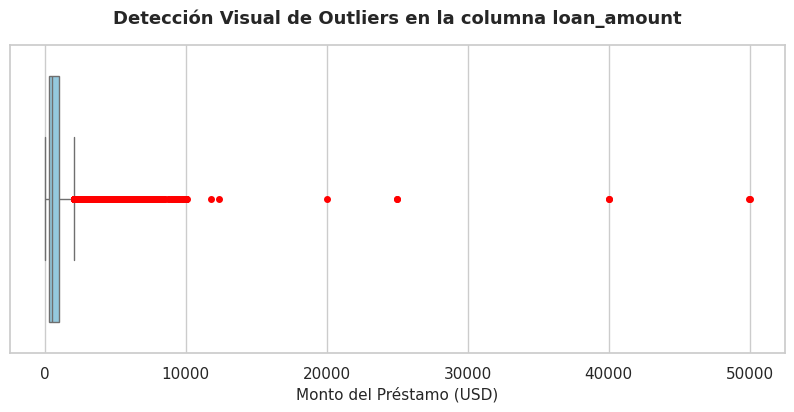

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo visual y el tamaño de la gráfica
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 4))

# Crear el gráfico de caja (Boxplot) para ver los valores atípicos
# Los puntos rojos que verás hacia la derecha representan tus 3,146 outliers
sns.boxplot(x=df['loan_amount'], color='skyblue',
            flierprops={"markerfacecolor":"red", "markeredgecolor":"red", "markersize": 4})

# Añadir títulos académicos aclaratorios para la entrega del proyecto
plt.title('Detección Visual de Outliers en la columna loan_amount', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Monto del Préstamo (USD)', fontsize=11)

# Desplegar el gráfico interactivo en Colab
plt.show()


Las siguientes celdas van a tratar de crear columnas derivadas de otras que contengan información útil.

Con ello pueden crearse ratios y medirse distancias que faciliten la visualización de los datos

In [ ]:
#Con este código separamos la columna posted_time en 3 columnas distintas (manteniendo la de posted_time)
#La primera línea crea una columna con el año, la segunda línea crea otra con el mes, y la última crea una columna con el nombre del día.
df['año_publicacion'] = df['posted_time'].dt.year
df['mes_publicacion'] = df['posted_time'].dt.month
df['dia_semana_publicacion'] = df['posted_time'].dt.day_name()

In [ ]:
#Con este código visualizamos:
# El tiempo que un prestatario tarda en recibir el dinero desde que la solicitud se publica en la web de Kiva
# El tiempo que un prestatario tarda en devolver el préstamo

#En Kiva, normalmente se da el dinero a través de un Partner antes de que se publique la solicitud en su web
#Esto da a los prestatarios inmediatez en la obtención de liquidez

df['dias_hasta_financiacion'] = (df['funded_time'] - df['disbursed_time']).dt.days
df['dias_hasta_desembolso'] = (df['disbursed_time'] - df['posted_time']).dt.days
df['dias_de_publicación'] = (df['funded_time'] - df['posted_time']).dt.days
print(df[['id','dias_hasta_financiacion', 'dias_hasta_desembolso','dias_de_publicación']].head())

        id  dias_hasta_financiacion  dias_hasta_desembolso  \
0  1175609                       31                    -23   
1  1056732                       25                    -20   
2   773348                       15                     -5   
3  1076908                       23                    -18   
4   680170                       27                     -2   

   dias_de_publicación  
0                    8  
1                    6  
2                   11  
3                    6  
4                   26  


In [ ]:
#Con este código podemos visualizar el porcentaje de financiación realizada
#Y la diferencia entre los prestado y devuelto

df['porcentaje_financiacion'] = (df['funded_amount'] / df['loan_amount'])*100
df['diferencia_financiacion'] = df['loan_amount'] - df['funded_amount']
print(df[['id','porcentaje_financiacion', 'diferencia_financiacion']].head())

        id  porcentaje_financiacion  diferencia_financiacion
0  1175609                    100.0                      0.0
1  1056732                    100.0                      0.0
2   773348                    100.0                      0.0
3  1076908                    100.0                      0.0
4   680170                    100.0                      0.0


In [ ]:
#Con este código ordenamos la columna "borrowe_genders" de manera que quede claro tanto
#el sexo de los prestatarios como el número total de ellos

df['num_prestatarios'] = df['borrower_genders'].str.split(',').str.len()
df['pct_mujeres'] = df['borrower_genders'].str.count('female') / df['num_prestatarios']
df['es_grupo'] = df['num_prestatarios'] > 1
print(df[['id','num_prestatarios', 'pct_mujeres', 'es_grupo']].head())

        id  num_prestatarios  pct_mujeres  es_grupo
0  1175609                 1          1.0     False
1  1056732                 1          0.0     False
2   773348                 1          1.0     False
3  1076908                 1          1.0     False
4   680170                 1          1.0     False


En la siguiente celda vamos a intentar codificar variables categóricas.

Teniendo en cuenta nuestro dataset, podemos considerar como variables categóricas los países donde se realizan los préstamos, los sectores donde se producen, la clase de actividad, la moneda en la que se paga el préstamo, etc.

Aunque estas variables pueden considerarse categorías, deben descartarse al tener una gran cantidad de variables. Hay 181 actividades distintas, que ocuren en 49 sectores en 95 países distintos.

Podríamos agrupar estas variables por ejemplo, por contintentes (respecto a los países y tipos de moneda), o por ejemplo, los sectores y actividades, por sectores primario, secundario y terciario.

Sin embargo, hay una variable que sólo tiene 3 variables, sirviéndonos de gran ejemplo.

In [ ]:
# Antes de nada, comprobamos los valores únicos (ya los conocemos: monthly, irregular, bullet)
if 'repayment_interval' in df.columns:
    print(df['repayment_interval'].value_counts(dropna=False))

    # One-hot encoding
    df = pd.get_dummies(df, columns=['repayment_interval'], prefix='repayment', dummy_na=True)
    # Esto añade una 4ª columna: repayment_nan, que marca con 1 las filas que tenían valor faltante
else:
    # Este mensaje nos informa de que ya no existe la columna repayment_interval,
    # y que ya ha sido sustituida por las 4 nuevas columnas creadas con el one-hot encoding
    print("La columna 'repayment_interval' no se encuentra en el DataFrame. Es posible que ya se haya codificado.")

# Esto crea 4 columnas nuevas: repayment_monthly, repayment_irregular, repayment_bullet, repayment_nan
# con valores binarios (True/False o 1/0)
print(df.filter(like='repayment_').head())

repayment_interval
monthly      22980
irregular    15009
bullet        4319
Name: count, dtype: int64
   repayment_bullet  repayment_irregular  repayment_monthly  repayment_nan
0             False                False               True          False
1             False                False               True          False
2             False                 True              False          False
3             False                 True              False          False
4             False                 True              False          False


En la celda final crearemos un archivo .csv.

Este archivo tendrá todas las modificaciones y limpiezas que hemos ido realizando a lo largo del notebook.

In [ ]:
df.to_csv('kiva_loans_clean.csv', index=False)
df.head()

,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,...,dias_de_publicación,porcentaje_financiacion,diferencia_financiacion,num_prestatarios,pct_mujeres,es_grupo,repayment_bullet,repayment_irregular,repayment_monthly,repayment_nan
0,1175609,525.0,525.0,personal medical expenses,health,to buy medicines for her son’s treatment at th...,TJ,tajikistan,Kanibadam,tjs,...,8,100.0,0.0,1,1.0,False,False,False,True,False
1,1056732,350.0,350.0,butcher shop,food,to buy a refrigerator for his butcher shop,MX,mexico,Ecatepec,mxn,...,6,100.0,0.0,1,0.0,False,False,False,True,False
2,773348,225.0,225.0,food,food,to buy more raw ingredients for making food sn...,PH,philippines,"Plaridel-Unidos, Plaridel, Misamis Occidental",php,...,11,100.0,0.0,1,1.0,False,False,True,False,False
3,1076908,325.0,325.0,farming,agriculture,to purchase sacks of fertilizer,PH,philippines,"Pagadian City, Zamboanga del Sur",php,...,6,100.0,0.0,1,1.0,False,False,True,False,False
4,680170,500.0,500.0,poultry,agriculture,To purchase more broiler chicks,ZW,zimbabwe,Nyanga,usd,...,26,100.0,0.0,1,1.0,False,False,True,False,False
